# **Project 2: Implementing Simple Linear Regression with Ordinary Least Squares (OLS) and Sum of Squared Errors (SSE) equations**

## **Objective**
In this assignment, you will implement simple linear regression from scratch using only NumPy and base Python. You will:

- Express linear regression in **matrix notation**.
- Compute the **line of best fit** using **OLS**.
- Calculate the **sum of squared errors (SSE)** to evaluate the model.

By the end of this assignment, you will understand how to derive and implement **linear regression** in its fundamental mathematical form.

---

## **Background**

### **Linear Regression Equation**
Simple linear regression is expressed as:


\begin{equation}
y = mx + b
\end{equation}


where:
- \( y \) is the **dependent variable** (target),
- \( x \) is the **independent variable** (feature),
- \( m \) is the **slope** (coefficient),
- \( b \) is the **y-intercept**.

---

### **Matrix Form**
We can express the equation in **matrix notation**:

\begin{equation}
Y = X \beta
\end{equation}

where:
- \$ Y \$ is an \$ n \times 1 \$ vector of observed values:

  \begin{aligned}
  Y =
  \begin{bmatrix}
  y_1 \\
  y_2 \\
  \vdots \\
  y_n
  \end{bmatrix}
  \end{aligned}

- \$ X \$ is an \$ n \times 2 \$ **design matrix**, where the first column consists of ones (for the intercept) and the second column contains the \$ x \$ values:

  \begin{aligned}
  X =
  \begin{bmatrix}
  1 & x_1 \\
  1 & x_2 \\
  \vdots & \vdots \\
  1 & x_n
  \end{bmatrix}
  \end{aligned}

- \$ \beta \$ is a \$ 2 \times 1 \$ vector containing the intercept \$( b \$) and slope \$( m \$):

  \begin{aligned}
  \beta =
  \begin{bmatrix}
  b \\
  m
  \end{bmatrix}
  \end{aligned}

Thus, our model can be rewritten as:

\begin{aligned}
\begin{bmatrix}
y_1 \\
y_2 \\
\vdots \\
y_n
\end{bmatrix}
&=
\begin{bmatrix}
1 & x_1 \\
1 & x_2 \\
\vdots & \vdots \\
1 & x_n
\end{bmatrix}
\begin{bmatrix}
b \\
m
\end{bmatrix}
\end{aligned}

---

### **Computing the Best Fit Line Using the ordinary least squares (OLS)**
The **best fit line** is obtained using the **ordinary least squares (OLS)**:

\begin{equation}
\beta = (X^T X)^{-1} X^T Y
\end{equation}

where:
- \$ X^T \$ is the transpose of \$ X \$,
- \$ (X^T X)^{-1} \$ is the **inverse** of \$ X^T X \$,
- \$ X^T Y \$ is the product of the transposed \$ X \$ and \$ Y \$.
---

### **Sum of Squared Errors (SSE)**
The **sum of squared errors (SSE)** is used to measure how well the regression line fits the data:


\begin{equation}
SSE = \frac{1}{n}\sum_{i=1}^{n} \|y_i - \hat{y}_i\|^2
\end{equation}

where:
- \$ y_i \$ represents the actual observed values,
- \$ \hat{y}_i \$ are the predicted values from the model.

Alternatively, using matrix notation:

\begin{equation}
SSE = (Y - X \beta)^T (Y - X \beta)
\end{equation}

where \$ Y - X\beta \$ represents the **residuals** (differences between actual and predicted values).

---

### **Coding**


###1. Import Required Libraries
For this lab only use NumPy, Pandas, Matplotlib, and base Python.

In [150]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

###2. Data

* We have a data set that describes 506 suburbs in Boston. Find the documentation for the variables [here](https://islp.readthedocs.io/en/latest/datasets/Boston.html).
* *Goal*: Predict the median value (in $1000s) of houses owned in that suburb.
* *Task*: Use the covariates / indepednent variables from the data set to create 3 different types of predictive models: single variable, multivariable, and polynomial regression.

**First step: import the data, split into x and y, and turn them into numpy arrays.**

In [151]:
#https://islp.readthedocs.io/en/latest/datasets/Boston.html
df = pd.read_csv('https://raw.githubusercontent.com/intro-stat-learning/ISLP/refs/heads/main/ISLP/data/Boston.csv')
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [152]:
# remove the last column because we cannot use the dependent variable in the model
x = df.iloc[:, :-1]
x.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33


**Begin with a single variable model, selecting the 6th column: 'rm' (average number of rooms per dwelling)**

In [153]:
# Starting with single linear regression
x = df.iloc[:, 5:6]
x.head()

,rm
0,6.575
1,6.421
2,7.185
3,6.998
4,7.147


**Select the target variable that we want to predict: medv (median value of owner-occupied homes in $1000s)**

In [154]:
y = df.iloc[:, -1:]
y.head()

,medv
0,24.0
1,21.6
2,34.7
3,33.4
4,36.2


**Turn both data frame objects into numpy arrays.**

In [155]:
y = df.iloc[:, -1:].to_numpy()
x = df.iloc[:, 5:6].to_numpy()

###3. Prepare Data in Matrix Form

#### 3a. Convert 𝑥 into matrix form by adding a column of ones for the intercept.

In [156]:
def prepare_matrix(x):
    n = len(x)
    X = np.column_stack((np.ones(n), x))  # Shape (n, 2)
    return X

X = prepare_matrix(x)
Y = y.reshape(-1, 1)  # Reshape y to column vector (aka. nx1 matrix)

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (506, 2)
Y shape: (506, 1)


#### 3b. Standardize the data. **(2 points)**

In [157]:
# insert your code for standardizing the data
x_mean = np.mean(x, axis=0)
x_std  = np.std(x, axis=0)

x = (x - x_mean) / x_std

# Rebuild X and Y after standardizing
X = prepare_matrix(x)
Y = y.reshape(-1, 1)


#### 3c. *Why do we add a column of ones to the 𝑋 matrix?*  **(2 points)**

**Answer:**

We add a column of ones so that when X is multiplied by β, the intercept term b is included in every prediction. Without it, the regression line would be forced through the origin.

#### 3d. *Why do we need to standardize our data for linear regression?*  **(2 points)**
**Answer:**

We standarize our data for linear regression so that the predicator variables are on the same scale. If they were different scales there may be some larger that could create distorsion.

#### 3e. *Why do we only standardize the 𝑋 matrix?* **(2 points)**
**Answer:**

We standardize X so that all features are on the same scale and comparable. Y doesn't need standardizing since it's a single variable with no scaling conflicts.

### 4. Compute the Best Fit Line Using OLS
#### 4a. Use the formula for Ordinary Least Squares (OLS) Regression to compute the $\beta$ vector. (Hint: Review Lab 4) **(2 points)**

In [158]:
# Compute beta vector
beta = np.linalg.inv(X.T @ X) @ X.T @ Y

print("Beta vector:", beta)

Beta vector: [[22.53280632]
 [ 6.38897522]]


#### 4b. *Explain how OLS finds the line of best fit.* **(2 points)**

**Answer:**

OLS finds the line of best fit by choosing the slope and intercept that minimize the sum of squared differences between the actual and predicted values.

###5. Using your computed values for $\beta$, generate the predicted values for the training data.
#### 5a. Use the computed $\beta$ to find the predictions $\hat{Y}$ using matrix multiplication with the design matrix X. **(2 points)**

In [159]:
# Create variable Y_pred (a list of predictions for each suburb)
def predict(X, beta):
    return X @ beta


In [160]:
# Create variable Y_pred (a list of predictions for each suburb)
def predict(X, beta):
    return X @ beta

Y_pred = predict(X, beta)
print(Y_pred)

[[25.17574577]
 [23.77402099]
 [30.72803225]
 [29.02593787]
 [30.38215211]
 [23.85593997]
 [20.05125842]
 [21.50759586]
 [16.5833549 ]
 [19.97844155]
 [23.3735282 ]
 [20.02395209]
 [18.93169901]
 [19.47782555]
 [20.81583557]
 [18.43108302]
 [19.35039603]
 [19.85101202]
 [14.99048582]
 [17.45715736]
 [16.02812625]
 [19.6234593 ]
 [21.23453259]
 [18.23993873]
 [19.25027283]
 [16.29208741]
 [18.23993873]
 [20.36983223]
 [24.44757706]
 [26.07685456]
 [17.32972783]
 [20.59738496]
 [19.48692766]
 [17.22050253]
 [20.81583557]
 [19.33219181]
 [18.49479778]
 [18.57671676]
 [19.63256141]
 [25.35778795]
 [29.26259271]
 [26.95065703]
 [21.48028953]
 [21.86257811]
 [20.57007863]
 [17.04756245]
 [17.99418179]
 [20.21509638]
 [14.47166561]
 [16.31939374]
 [19.60525508]
 [20.98877564]
 [24.5932108 ]
 [19.92382889]
 [18.9225969 ]
 [31.31056723]
 [23.42814085]
 [27.36935404]
 [21.26183891]
 [19.27757916]
 [17.58458688]
 [19.63256141]
 [24.09259481]
 [26.87784015]
 [29.99076143]
 [22.58164472]
 [18.00328

#### *5b. What does the y_pred array respresent?* **(2 points)**


**Answer:**

Y_pred represents the predicted median house values (in standardized form) for each of the 506 Boston suburbs, calculated using the regression line derived from the number of rooms (RM) variable.


### 6. Calculate the normalized Sum of Squared Errors (SSE) for the model.
#### 6a. Compute the SSE to measure how well the regression model fits the training data. **(2 points)**

> **Important:** In this assignment, whenever we say “SSE,” we mean the **normalized** version:
> \[
> \text{SSE} = \frac{1}{n}\sum_{i=1}^{n}(y_i-\hat y_i)^2
> \]
> where \(n\) is the number of samples used in that SSE calculation (train or test). This makes train/test errors comparable even when the split sizes differ.


In [161]:
# Compute the **normalized** SSE (SSE/n) and store it in the variable `sse`.
# SSE = (1/n) * sum_i (y_i - yhat_i)^2, where n = number of samples used in this SSE.
# TODO: implement below

n = len(Y)
sse = (1/n) * np.sum((Y - Y_pred)**2)
print("SSE:", sse)


SSE: 43.60055177116956


#### *6b. How does SSE relate to the goodness of fit of the model? In other words, what do we want SSE to be?* **(2 points)**


**Answer:**

SSE measures how far the predicted values are from the actual values. We want SSE to be as close to 0 as possible, as a lower SSE means the model's predictions are closer to the actual values and therefore a better fit.

### 7. Visualize the resulting regression model and line of best fit. Plot the data alongside the line of best fit.

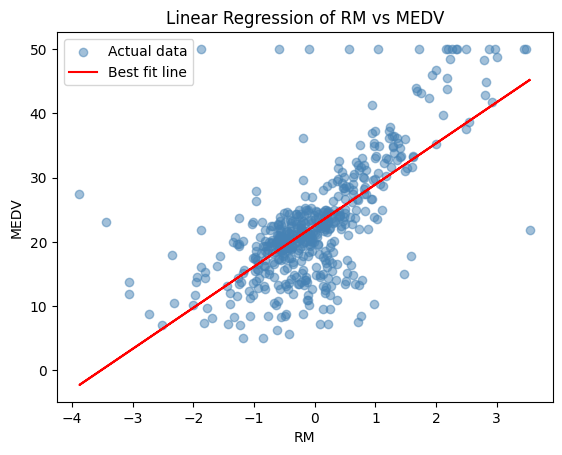

In [162]:
plt.scatter(x, y, color="steelblue", alpha=0.5, label="Actual data")
plt.plot(x, Y_pred, color= "red", label= "Best fit line")
plt.xlabel("RM")
plt.ylabel("MEDV")
plt.title("Linear Regression of RM vs MEDV")
plt.legend()
plt.show()

### 8. The above plot looks at the relationship between *rm* (an independent variable) and *mdev* (the dependent variable we are trying to predict). Create a single ordinary least squares (OLS) regression with a different independent variable (other than *rm*) from our data set. Once you have your predictions, plot the line of best fit with your chosen independent variable on the x-axis and *mdev* on the y-axis. **(2 points)**

SSE: 72.42398092899334


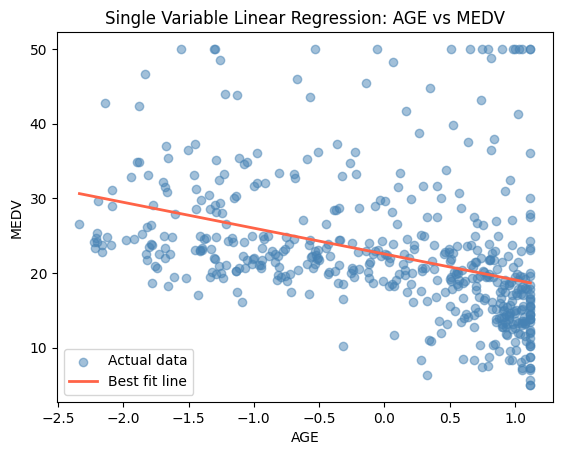

In [163]:
x2 = df.iloc[:, 6:7].to_numpy()
y2 = df.iloc[:, -1:].to_numpy()

# Standardize
x2 = (x2 - np.mean(x2)) / np.std(x2)

# Build design matrix and compute beta
X2 = prepare_matrix(x2)
Y2 = y2.reshape(-1, 1)
beta2 = np.linalg.inv(X2.T @ X2) @ X2.T @ Y2

# Predict and compute SSE
Y2_pred = predict(X2, beta2)
sse2 = (1/len(Y2)) * np.sum((Y2 - Y2_pred)**2)
print("SSE:", sse2)

# Sort by x for a clean line
sort_idx = x2.flatten().argsort()

plt.scatter(x2, y2, color="steelblue", alpha=0.5, label="Actual data")
plt.plot(x2[sort_idx], Y2_pred[sort_idx], color="tomato", linewidth=2, label="Best fit line")
plt.xlabel("AGE")
plt.ylabel("MEDV")
plt.title("Single Variable Linear Regression: AGE vs MEDV")
plt.legend()
plt.show()

### 9.
To this point, you've trained a single variable linear regression on just the training data. This tells us how the model will perform on data we already have, but not on actual data we recieve in the future. To get a better understanding of how the data will run on unseen data, we need to split our data into training and testing data.


Now, train a single linear regression model using a train/test split. Identify how the mdoel does on the training vs testing data.

#### 9a. Split the data into a training and test split. In the training set, keep 80% of the observations. In the test set, keep the other 20% of observations. **(2 points)**

In [164]:
# Split into Training and Testing Sets (80% of the data should be in your training array and 20% of your data should be in your test array)
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)



#### 9b. With your training data, train the model by minimizing the Sum of Squared Errors (normalized SSE (SSE/n)). You will have one coefficient for the intercept term $(\beta_0)$ and another for your chosen independent variable ($\beta_1$). **(10 points)**

> Reminder: use **SSE = (1/n)·∑(y-ŷ)^2** with n equal to the sample size for that split.


In [165]:
# Train model by minimizing the (normalized) SSE.
# Note: dividing SSE by n does NOT change the optimal coefficients (it only rescales the objective).
# TODO: implement training below

X_train = prepare_matrix(x_train)
Y_train = y_train.reshape(-1, 1)

# Compute beta using OLS
beta_train = np.linalg.inv(X_train.T @ X_train) @ X_train.T @ Y_train

print("Intercept (b):", beta_train[0, 0])
print("Slope     (m):", beta_train[1, 0])

Intercept (b): 22.50433758446667
Slope     (m): 6.561783228006272


#### 9c. Using your trained model ($\beta$ coefficients), calculate your predictions on the training data set. Compare your predictions with the true values of *mdev* in the train set by computing the normalized SSE (SSE/n). Report your value of normalized SSE (SSE/n). **(5 points)**

> Reminder: use **SSE = (1/n)·∑(y-ŷ)^2** with n equal to the sample size for that split.


In [166]:
# Evaluate your trained model on the training data.
# Compute the **normalized** SSE (SSE/n) on the TRAIN split.
# TODO: compute sse_train below

X_train = prepare_matrix(x_train)
Y_train = y_train.reshape(-1, 1)
beta_train = np.linalg.inv(X_train.T @ X_train) @ X_train.T @ Y_train
Y_train_pred = predict(X_train, beta_train)

n_train = len(Y_train)
sse_train = (1/n_train) * np.sum((Y_train - Y_train_pred)**2)
print("Training SSE:", sse_train)


Training SSE: 42.99661556265404


#### 9d. Now use your trained model to calculate your predictions on the test data set. Compute the normalized SSE (SSE/n) on the test data set. **(5 points)**

> Reminder: use **SSE = (1/n)·∑(y-ŷ)^2** with n equal to the sample size for that split.


In [167]:
# Evaluate your trained model on the test data.
# Compute the **normalized** SSE (SSE/n) on the TEST split.
# TODO: compute sse_test below

X_test = prepare_matrix(x_test)
Y_test = y_test.reshape(-1, 1)
Y_test_pred = predict(X_test, beta_train)

n_test = len(Y_test)
sse_test = (1/n_test) * np.sum((Y_test - Y_test_pred)**2)
print("Test SSE:", sse_test)



Test SSE: 46.14477534731726


#### 9e. How does the SSE on the test set compare to the SSE on the training set? **(2 points)**

**Answer:**

The training SSE (42.997) is slightly lower than the Testing SSE whivh was 46.144. this is expected as the model was able to be fit on the training data.


### 9f. Plot (like in Question 7) your line of best fit over your training data. **(2 points)**

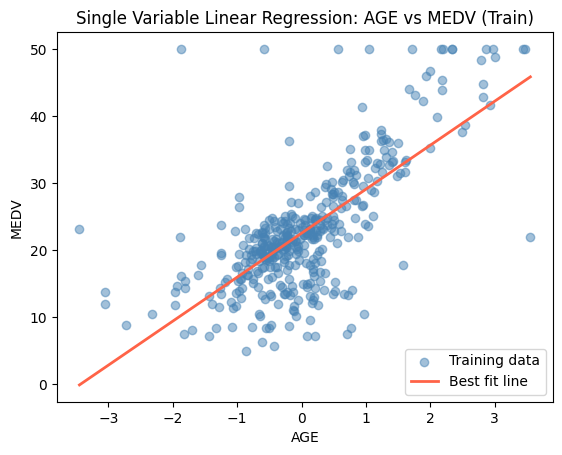

In [168]:
# Plot here

sort_idx = x_train.flatten().argsort()

plt.scatter(x_train, y_train, color="steelblue", alpha=0.5, label="Training data")
plt.plot(x_train[sort_idx], Y_train_pred[sort_idx], color="tomato", linewidth=2, label="Best fit line")
plt.xlabel("AGE")
plt.ylabel("MEDV")
plt.title("Single Variable Linear Regression: AGE vs MEDV (Train)")
plt.legend()
plt.show()


### 9g. Plot (like in Question 7) your line of best fit over your test data. **(2 points)**

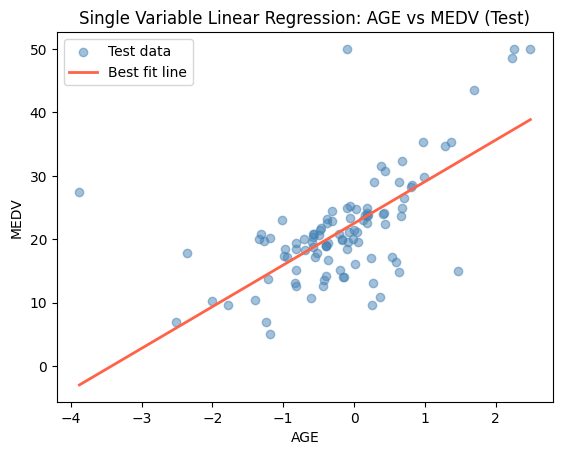

In [169]:
# Plot here
sort_idx = x_test.flatten().argsort()

plt.scatter(x_test, y_test, color="steelblue", alpha=0.5, label="Test data")
plt.plot(x_test[sort_idx], Y_test_pred[sort_idx], color="tomato", linewidth=2, label="Best fit line")
plt.xlabel("AGE")
plt.ylabel("MEDV")
plt.title("Single Variable Linear Regression: AGE vs MEDV (Test)")
plt.legend()
plt.show()



### 10. The models you have created thus far are only examples of single ordinary least squares. What if we want to include more than one independent variable in our prediction? Train a multiple linear regression model which incorporates all of the available independent variables in the data set. Using your model, predict the median house value. Compare your results on the training data set vs the test data set again. **(10 points)**

> Reminder: when comparing train vs test error, use **normalized SSE = (1/n)·∑(y-ŷ)^2**.


In [170]:
### Modify your code for multiple linear regression (use all non-label columns available to train a model to predict median house value)
#Hint: remove the last column because we cannot use the dependent variable in the model

# Use all independent variables
X_multi = df.iloc[:, :-1].to_numpy()
y_multi = df.iloc[:, -1:].to_numpy()

# Standardize
X_multi = (X_multi - np.mean(X_multi, axis=0)) / np.std(X_multi, axis=0)

# Train/test split
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

# Build design matrices
X_train_m = prepare_matrix(X_train_m)
X_test_m  = prepare_matrix(X_test_m)
Y_train_m = y_train_m.reshape(-1, 1)
Y_test_m  = y_test_m.reshape(-1, 1)

# Compute beta using OLS
beta_multi = np.linalg.inv(X_train_m.T @ X_train_m) @ X_train_m.T @ Y_train_m

# Predictions
Y_train_m_pred = predict(X_train_m, beta_multi)
Y_test_m_pred  = predict(X_test_m, beta_multi)

# Normalized SSE
sse_train_m = (1/len(Y_train_m)) * np.sum((Y_train_m - Y_train_m_pred)**2)
sse_test_m  = (1/len(Y_test_m))  * np.sum((Y_test_m  - Y_test_m_pred)**2)

print("Multivariable Training SSE:", sse_train_m)
print("Multivariable Test SSE:    ", sse_test_m)


Multivariable Training SSE: 22.60428647941742
Multivariable Test SSE:     22.77770856386616


### 11. The model you made in the previous question only had linear terms of our features. Sometimes, we want to capture more complicated relationships between variables. To add more complexity to our model, experiment with differnet polynomial models. For each model, try to think about whether you may be overfitting or underfitting to the training data. Again, compare your performnance on the training data vs the testing data.

#### 11a. Modify the design matrix to include polynomial terms of degree 2. (Hint: add squared values of existing columns to the deign matrix X). Calculate the normalized SSE (SSE/n) on the training and testing data sets. **(10 points)**

> Reminder: use **SSE = (1/n)·∑(y-ŷ)^2** with n equal to the sample size for that split.


In [171]:
### Modify for polynomial regression (degree 2)
# Reminder: when reporting SSE in this section, use **normalized SSE** = sum((y - yhat)^2) / n.
# TODO: build your degree-2 design matrix, fit coefficients, and compute train/test normalized SSE.

X_poly = df.iloc[:, :-1].to_numpy()
y_poly = df.iloc[:, -1:].to_numpy()

X_poly = (X_poly - np.mean(X_poly, axis=0)) / np.std(X_poly, axis=0)
X_poly2 = np.hstack([X_poly, X_poly**2])

X_train_p2, X_test_p2, y_train_p2, y_test_p2 = train_test_split(X_poly2, y_poly, test_size=0.2, random_state=42)

X_train_p2 = prepare_matrix(X_train_p2)
X_test_p2  = prepare_matrix(X_test_p2)
Y_train_p2 = y_train_p2.reshape(-1, 1)
Y_test_p2  = y_test_p2.reshape(-1, 1)

beta_poly2      = np.linalg.inv(X_train_p2.T @ X_train_p2) @ X_train_p2.T @ Y_train_p2
Y_train_p2_pred = predict(X_train_p2, beta_poly2)
Y_test_p2_pred  = predict(X_test_p2,  beta_poly2)

sse_train_p2 = (1/len(Y_train_p2)) * np.sum((Y_train_p2 - Y_train_p2_pred)**2)
sse_test_p2  = (1/len(Y_test_p2))  * np.sum((Y_test_p2  - Y_test_p2_pred)**2)

print("Degree 2 Training SSE:", sse_train_p2)
print("Degree 2 Test SSE:    ", sse_test_p2)

Degree 2 Training SSE: 15.052572373720473
Degree 2 Test SSE:     13.1623110783279


#### 11aa. After fitting your degree-2 model, make a quick visualization for sanity-checking. **(5 points)**

Using the **same single feature** you used back in Q9 (your chosen independent variable), plot:
1. The original data points \((x, y)\) as a scatter plot.
2. The fitted quadratic curve \(\hat{y} = a + bx + cx^2\) on top of the scatter plot.

> Tip: sort the x-values before plotting the curve so the line looks smooth.



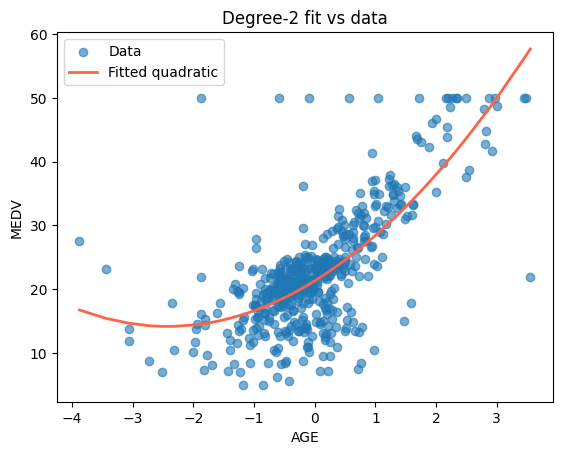

In [172]:
# 11aa: Plot datapoints and fitted quadratic yhat = a + b x + c x^2 (for your chosen feature from Q9)
import numpy as np
import matplotlib.pyplot as plt

x_feature = x.flatten()       # shape (n,)
y_true     = y.flatten()      # shape (n,)

# Fit degree-2 OLS on single feature to get a, b, c
X_vis  = prepare_matrix(np.column_stack([x_feature, x_feature**2]))
beta_v = np.linalg.inv(X_vis.T @ X_vis) @ X_vis.T @ y_true
a, b, c = beta_v[0], beta_v[1], beta_v[2]  # scalars (from your fitted quadratic on this feature)

# Make a smooth curve
x_sorted = np.sort(x_feature)
y_curve  = a + b * x_sorted + c * (x_sorted**2)

plt.figure()
plt.scatter(x_feature, y_true, alpha=0.6, label="Data")
plt.plot(x_sorted, y_curve, color="tomato", linewidth=2, label="Fitted quadratic")
plt.xlabel("AGE")
plt.ylabel("MEDV")
plt.title("Degree-2 fit vs data")
plt.legend()
plt.show()

#### 11b. To test how our model performs as we change the degree of our model. Train models of degree 1 to degree 8. This will result in 8 different models.  For each model you create, save the Sum of Squared Errors (normalized SSE (SSE/n)) on the training and test data set respectively. We will use them for the next step to plot how they change as the model becomes more complex. **(20 points)**

> Reminder: use **SSE = (1/n)·∑(y-ŷ)^2** with n equal to the sample size for that split.


In [173]:
### Fit polynomial models of degrees 1-8, save training and testing errors
# Reminder: store **normalized** SSE values for each split:
#   sse_k_train = sum((y_train - yhat_train)^2) / len(y_train)
#   sse_k_test  = sum((y_test  - yhat_test )^2) / len(y_test)
# TODO: implement loop over degrees below and save errors for plotting.

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_poly, y_poly, test_size=0.2, random_state=42)

sse_train_list = []
sse_test_list  = []

for degree in range(1, 9):
    X_train_d = np.hstack([X_train_b**d for d in range(1, degree+1)])
    X_test_d  = np.hstack([X_test_b**d  for d in range(1, degree+1)])

    X_train_d = prepare_matrix(X_train_d)
    X_test_d  = prepare_matrix(X_test_d)
    Y_train_d = y_train_b.reshape(-1, 1)
    Y_test_d  = y_test_b.reshape(-1, 1)

    beta_d          = np.linalg.inv(X_train_d.T @ X_train_d) @ X_train_d.T @ Y_train_d
    Y_train_d_pred  = predict(X_train_d, beta_d)
    Y_test_d_pred   = predict(X_test_d,  beta_d)

    sse_k_train = (1/len(Y_train_d)) * np.sum((Y_train_d - Y_train_d_pred)**2)
    sse_k_test  = (1/len(Y_test_d))  * np.sum((Y_test_d  - Y_test_d_pred)**2)

    sse_train_list.append(sse_k_train)
    sse_test_list.append(sse_k_test)

    print(f"Degree {degree} | Train SSE: {sse_k_train:.4f} | Test SSE: {sse_k_test:.4f}")

Degree 1 | Train SSE: 22.6043 | Test SSE: 22.7777
Degree 2 | Train SSE: 15.0526 | Test SSE: 13.1623
Degree 3 | Train SSE: 19.1046 | Test SSE: 19.0029
Degree 4 | Train SSE: 14.3400 | Test SSE: 14.0595
Degree 5 | Train SSE: 12.9531 | Test SSE: 13.5552
Degree 6 | Train SSE: 18.4695 | Test SSE: 23.7615
Degree 7 | Train SSE: 24.9973 | Test SSE: 36.0760
Degree 8 | Train SSE: 9.2972 | Test SSE: 30.7491


### Overfitting

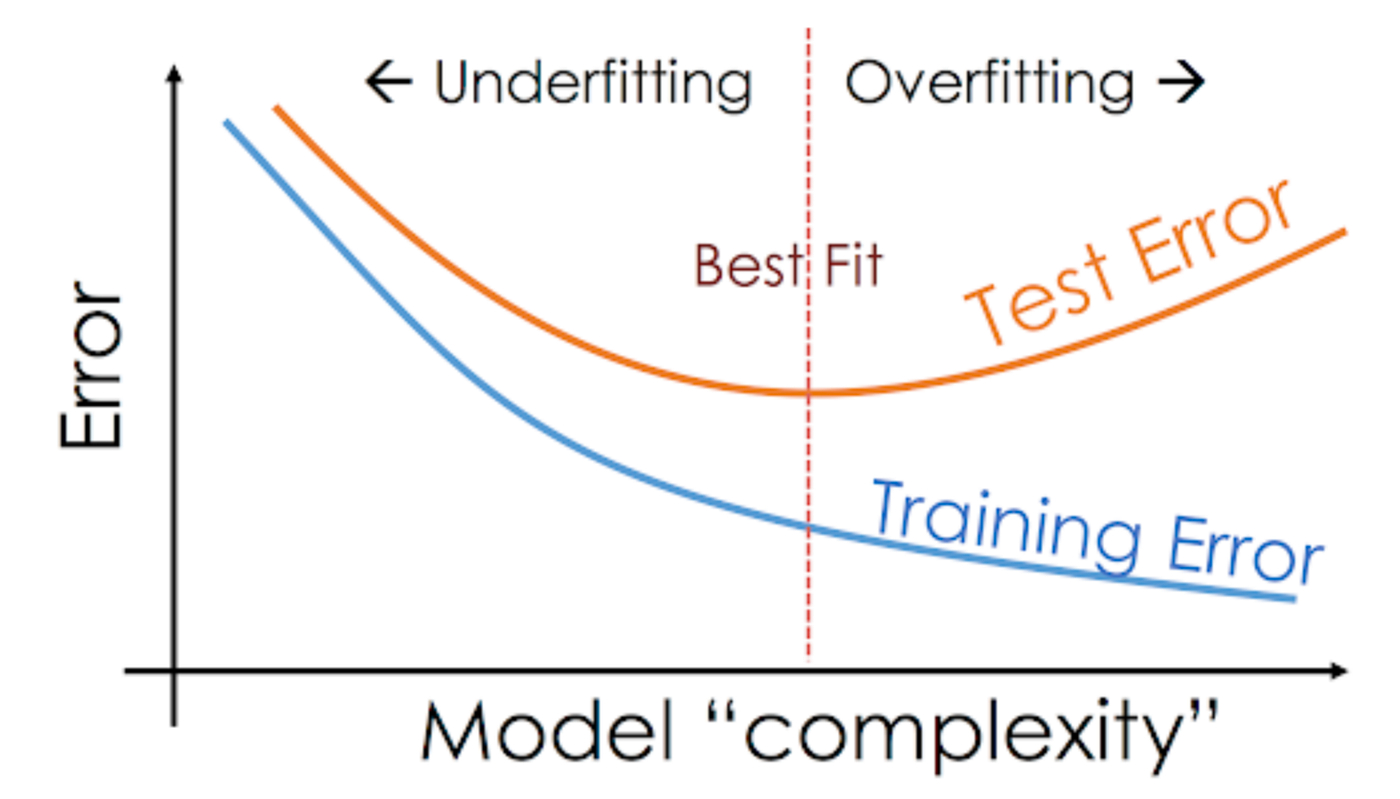

#### 11c. Using the training and testing normalized SSE (SSE/n) you calculated in the previous question, plot the errors for each model complexity. In this plot, the x-axis will be the model complexity (degree of the model) and the y-axis will be the normalized SSE (SSE/n) you calculated. What can you determine from this plot? How does the error on the training data set compare to the error on the testing data set as the degree of the model increases? **(10 points)**

> Reminder: use **SSE = (1/n)·∑(y-ŷ)^2** with n equal to the sample size for that split.


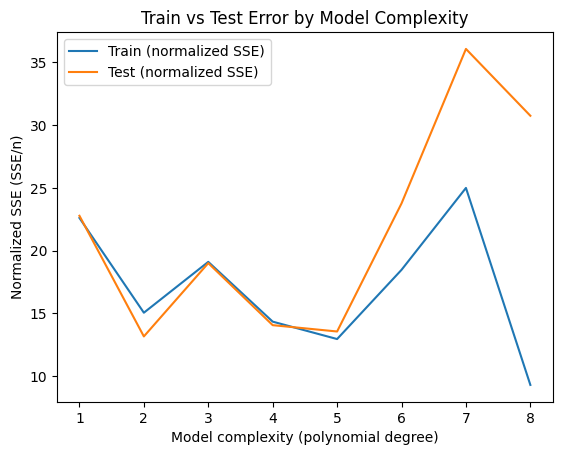

In [ ]:
###Graph training and testing errors on same line plot to show overfitting
#After you correct SSE everywhere (use normalized SSE), make sure this plot renders and matches the reference image above.
#TODO: replace `degrees`, `train_errors`, `test_errors` with your actual arrays/lists.

import matplotlib.pyplot as plt

# Example placeholders (replace with your computed values)
 
degrees = list(range(1, 9))  # Degrees 1 through 8

plt.figure()
plt.plot(degrees, sse_train_list, label= "Train (normalized SSE)")
plt.plot(degrees, sse_test_list,  label= "Test (normalized SSE)")
plt.xlabel("Model complexity (polynomial degree)")
plt.ylabel("Normalized SSE (SSE/n)")
plt.title("Train vs Test Error by Model Complexity")
plt.legend()
plt.show()